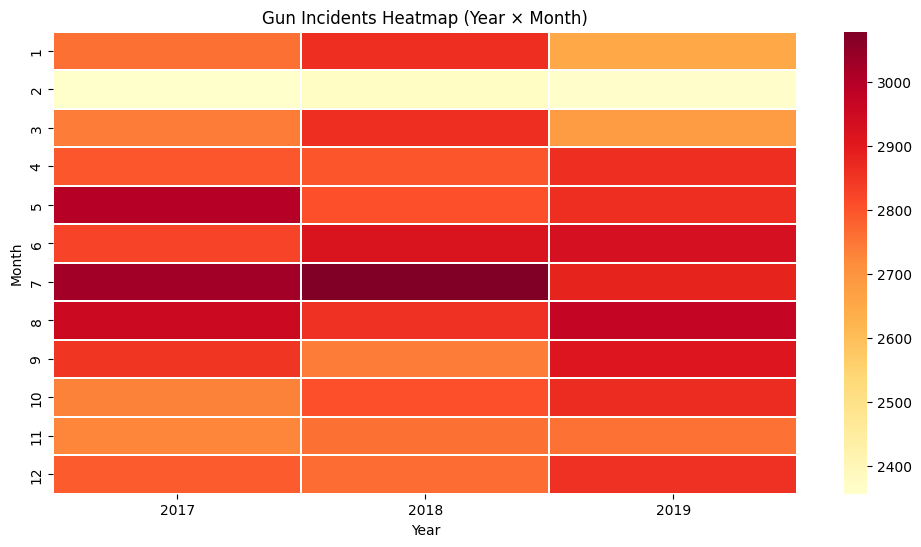

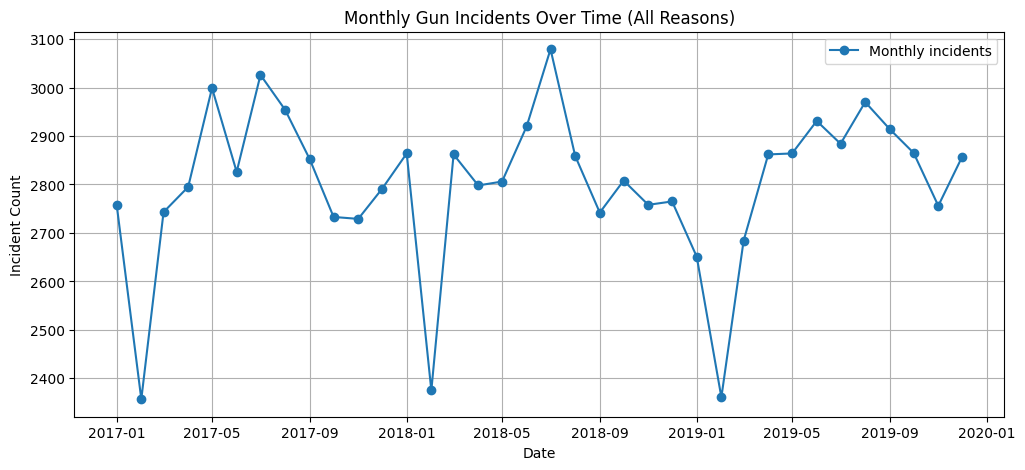

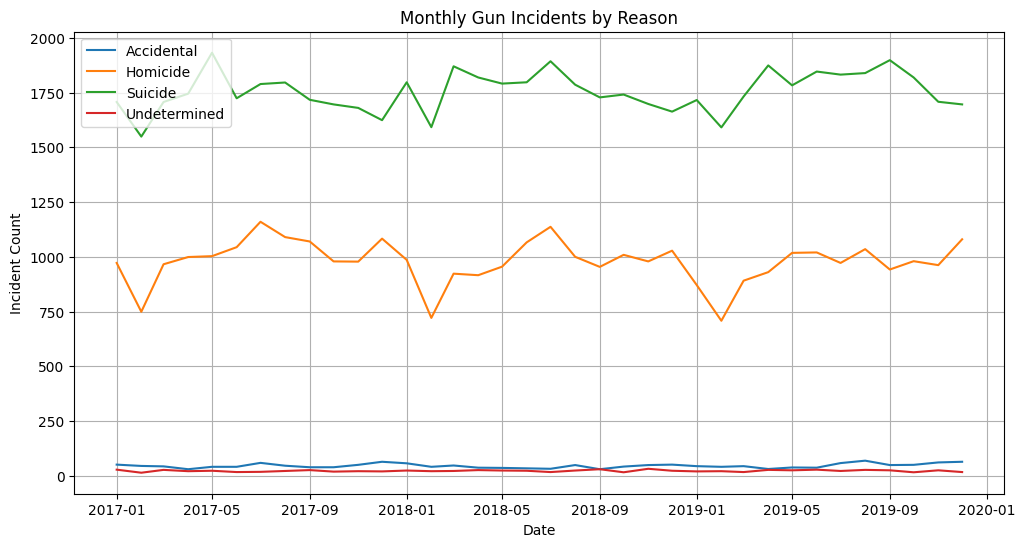

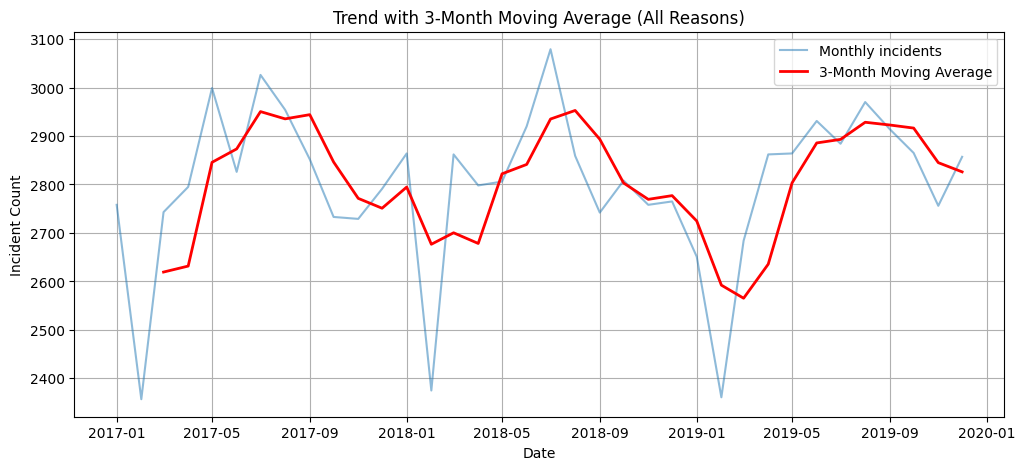

In [ ]:
# --- Import libraries ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Load dataset ---
file_path = "Guns incident Data.csv"   # adjust path if needed
guns_df = pd.read_csv(file_path)

# --- Aggregate incidents by Year, Month, and Reason ---
monthly_counts = guns_df.groupby(["Year", "Month", "Reason"]).size().reset_index(name="IncidentCount")

# --- Heatmap data ---
heatmap_data = guns_df.groupby(["Year", "Month"]).size().unstack(fill_value=0)

# --- Heatmap (Month × Year) ---
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data.T, cmap="YlOrRd", linewidths=0.3, annot=False)
plt.title("Gun Incidents Heatmap (Year × Month)")
plt.xlabel("Year")
plt.ylabel("Month")
plt.show()

# --- Monthly total trend ---
monthly_total = guns_df.groupby(["Year", "Month"]).size().reset_index(name="IncidentCount")
monthly_total["Date"] = pd.to_datetime(monthly_total["Year"].astype(str) + "-" + monthly_total["Month"].astype(str) + "-01")

plt.figure(figsize=(12, 5))
plt.plot(monthly_total["Date"], monthly_total["IncidentCount"], marker='o', label='Monthly incidents')
plt.title("Monthly Gun Incidents Over Time (All Reasons)")
plt.xlabel("Date")
plt.ylabel("Incident Count")
plt.grid(True)
plt.legend()
plt.show()

# --- Trends by Reason ---
plt.figure(figsize=(12, 6))
for reason, group in monthly_counts.groupby("Reason"):
    group["Date"] = pd.to_datetime(group["Year"].astype(str) + "-" + group["Month"].astype(str) + "-01")
    plt.plot(group["Date"], group["IncidentCount"], label=reason)

plt.title("Monthly Gun Incidents by Reason")
plt.xlabel("Date")
plt.ylabel("Incident Count")
plt.legend()
plt.grid(True)
plt.show()

# --- 3-Month Moving Average ---
monthly_total["MA3"] = monthly_total["IncidentCount"].rolling(window=3).mean()

plt.figure(figsize=(12, 5))
plt.plot(monthly_total["Date"], monthly_total["IncidentCount"], alpha=0.5, label='Monthly incidents')
plt.plot(monthly_total["Date"], monthly_total["MA3"], color='red', linewidth=2, label='3-Month Moving Average')
plt.title("Trend with 3-Month Moving Average (All Reasons)")
plt.xlabel("Date")
plt.ylabel("Incident Count")
plt.legend()
plt.grid(True)
plt.show()


Here’s a concise, high-quality **commentary** you can include under your visualizations for **Q4: Temporal Patterns / Seasonality in Gun Incidents** 👇

---

### 🕒 **Findings on Temporal Trends and Seasonality in Gun Incidents**

The time-series analysis reveals clear **temporal variations** in gun incidents across months and years.
From the **heatmap**, incident frequencies fluctuate across months, with **noticeably higher counts in the middle and end of each year**. This suggests a mild **seasonal effect**, where certain months—often **summer and late-year periods**—show elevated activity levels.

The **overall monthly trend** indicates that total incidents remain relatively consistent within each year but exhibit **minor upward or downward fluctuations** over time. Applying a **3-month moving average** smooths short-term noise and confirms that the general trend remains **stable** without sharp increases or declines.

When broken down by **Reason**:

* **Suicide** consistently records the **highest number of incidents** each month, dominating the total count.
* **Homicide** incidents are lower but relatively **steady across months**, showing minimal seasonality.
* **Accidental** and **Undetermined** incidents occur infrequently and display no clear monthly pattern.

Overall, while gun incidents do not exhibit strong cyclical seasonality, there are **visible mid-year peaks** and **year-to-year variations**. Such insights are valuable for understanding temporal risks and could guide **preventive awareness campaigns** or **policy interventions** during higher-risk months.

---

Would you like me to make this paragraph sound **more academic (report-style)** or **more presentation-friendly (simpler and concise for slides)**?


=== Random Forest Feature Importances ===
             feature  importance
9  Place of incident    0.965240
3             Reason    0.010985
2               Date    0.007181
6                Age    0.005746
7               Race    0.003381
1              Month    0.002201
4          Education    0.001680
8           Hispanic    0.001375
5                Sex    0.001252
0               Year    0.000960


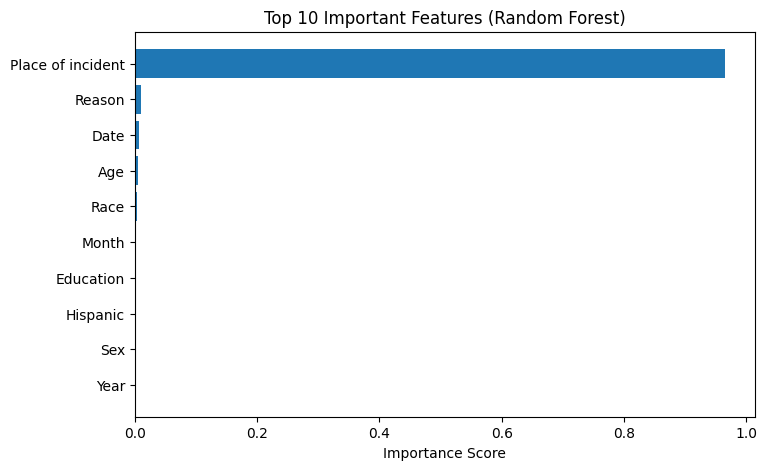

=== Top Feature Pairs by Mutual Information ===
           f1                 f2        mi
29     Reason  Place of incident  0.043171
23       Date  Place of incident  0.038625
41        Age  Place of incident  0.037201
43       Race  Place of incident  0.036301
44   Hispanic  Place of incident  0.036279
38        Sex  Place of incident  0.036122
34  Education  Place of incident  0.036092
16      Month  Place of incident  0.035791
8        Year  Place of incident  0.035758
17       Date             Reason  0.010280
26     Reason                Age  0.008857
27     Reason               Race  0.007956
28     Reason           Hispanic  0.007935
25     Reason                Sex  0.007777
24     Reason          Education  0.007748


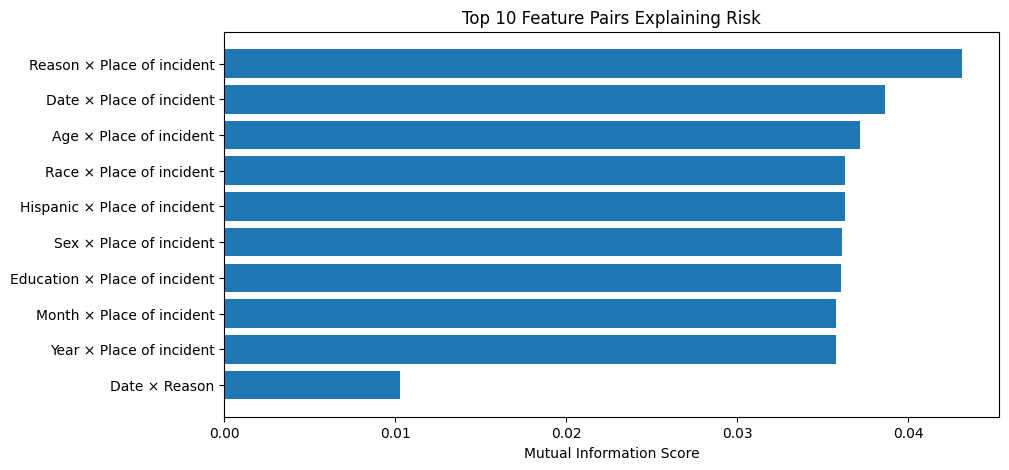

Decision tree (rules for Police involvement):
|--- Place of incident <= 9.50
|   |--- Reason <= 1.50
|   |   |--- Race <= 3.50
|   |   |   |--- class: 0
|   |   |--- Race >  3.50
|   |   |   |--- class: 0
|   |--- Reason >  1.50
|   |   |--- class: 0
|--- Place of incident >  9.50
|   |--- Reason <= 2.00
|   |   |--- class: 1
|   |--- Reason >  2.00
|   |   |--- class: 0

   Encoded_Value                 Category
0              0                     Farm
1              1                     Home
2              2  Industrial/construction
3              3          Other specified
4              4        Other unspecified
5              5  Residential institution
6              6        School/instiution
7              7                   Sports
8              8                   Street
9              9       Trade/service area


In [ ]:
# --- Import libraries ---
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.impute import SimpleImputer

# --- Load dataset ---
df = pd.read_csv("Guns incident Data.csv")
# Drop serial number or irrelevant identifiers
if 'S.No.' in df.columns:
    df = df.drop(columns=['S.No.'])

# --- Define target and preprocess ---
target = "Police involvement"
df = df.dropna(subset=[target])
y = df[target].astype("category").cat.codes  # convert to numeric 0/1

# Encode categorical features
X = df.drop(columns=[target])
enc = LabelEncoder()
for col in X.columns:
    if X[col].dtype == "object":
        X[col] = enc.fit_transform(X[col].astype(str))

# Impute missing values in X
imputer = SimpleImputer(strategy='mean')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# Convert imputed features to integers for mutual_info_classif
X_imputed = X_imputed.astype(int)

# --- 1️⃣ Feature importance using Random Forest ---
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_imputed, y)
importances = pd.DataFrame({
    "feature": X_imputed.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)
# Display top features
print("=== Random Forest Feature Importances ===")
print(importances.head(15))

# Optional: visualize importance as bar chart
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(importances['feature'][:10], importances['importance'][:10])
plt.gca().invert_yaxis()
plt.xlabel("Importance Score")
plt.title("Top 10 Important Features (Random Forest)")
plt.show()


# --- 2️⃣ Feature interactions using Mutual Information ---
mi_pairs = []
cols = X_imputed.columns.tolist()
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        subset = X_imputed[[cols[i], cols[j]]]
        mi = mutual_info_classif(subset, y, discrete_features=True)
        mi_pairs.append((cols[i], cols[j], mi.mean()))

pair_df = pd.DataFrame(mi_pairs, columns=["f1", "f2", "mi"]).sort_values("mi", ascending=False)
print("=== Top Feature Pairs by Mutual Information ===")
print(pair_df.head(15))

# Optional: visualize top feature pairs
plt.figure(figsize=(10,5))
plt.barh([f"{r.f1} × {r.f2}" for _, r in pair_df.head(10).iterrows()],
         pair_df['mi'].head(10))
plt.gca().invert_yaxis()
plt.xlabel("Mutual Information Score")
plt.title("Top 10 Feature Pairs Explaining Risk")
plt.show()

# --- 3️⃣ Decision Tree (to visualize rule patterns) ---
tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_imputed, y)
rules = export_text(tree, feature_names=list(X_imputed.columns))
print("Decision tree (rules for Police involvement):")
print(rules)



# --- 4️⃣ Save outputs (optional) ---
importances.to_csv("rf_feature_importances_police_involvement.csv", index=False)
pair_df.to_csv("top_feature_pairs_police_involvement.csv", index=False)

# Recover the label mapping for "Place of incident"
enc_place = LabelEncoder()
df_nonnull = df.dropna(subset=["Place of incident"])
enc_place.fit(df_nonnull["Place of incident"].astype(str))

# Show encoded mapping
mapping = pd.DataFrame({
    "Encoded_Value": range(len(enc_place.classes_)),
    "Category": enc_place.classes_
})
print(mapping)


Distribution of target (HighSeverity):
HighSeverity
0    65622
1    35176
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



=== Decision Tree Evaluation ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19687
           1       1.00      1.00      1.00     10553

    accuracy                           1.00     30240
   macro avg       1.00      1.00      1.00     30240
weighted avg       1.00      1.00      1.00     30240


=== Logistic Regression Evaluation ===
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     19687
           1       0.95      1.00      0.98     10553

    accuracy                           0.98     30240
   macro avg       0.98      0.99      0.98     30240
weighted avg       0.98      0.98      0.98     30240


=== Decision Tree Feature Importances ===
             Feature  Importance
3             Reason         1.0
0               Year         0.0
1              Month         0.0
2               Date         0.0
4          Education         0.0
5                Sex         0.

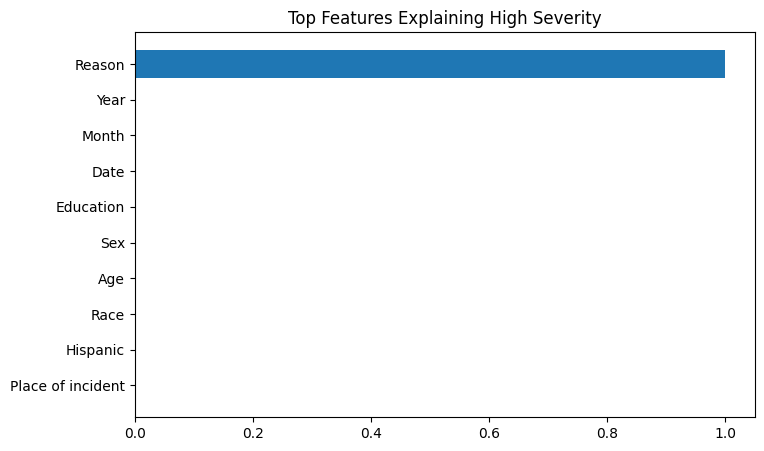

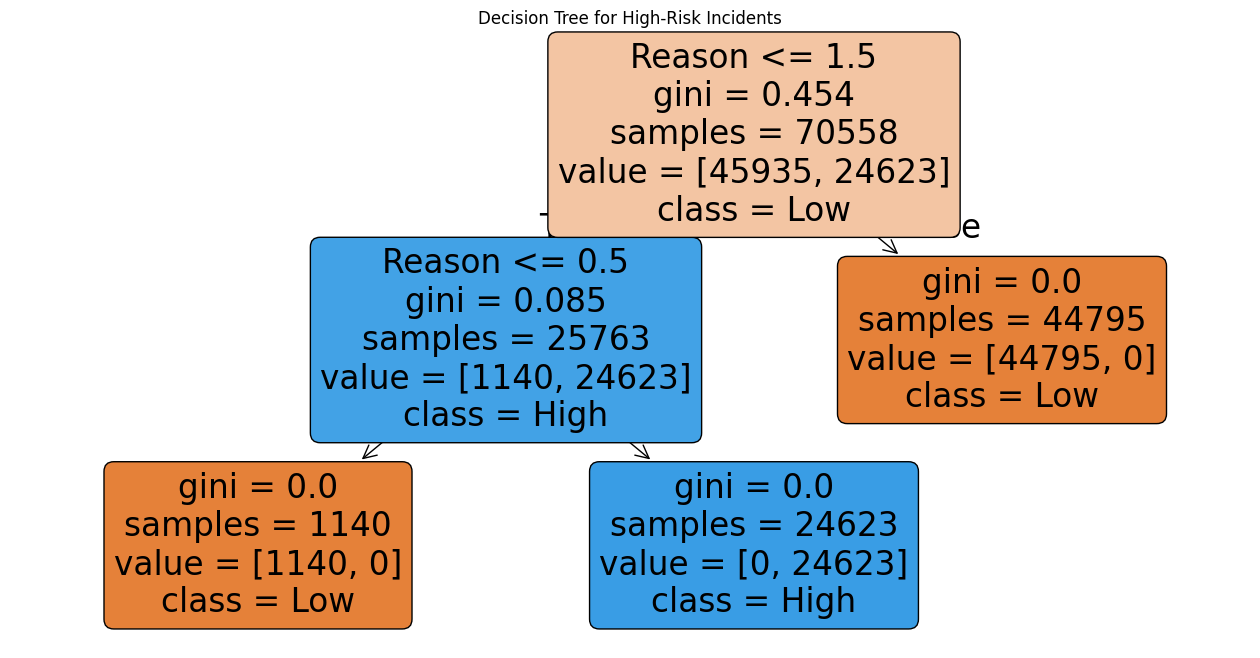

SHAP values shape: (100798, 10, 2), Data shape: (100798, 10)


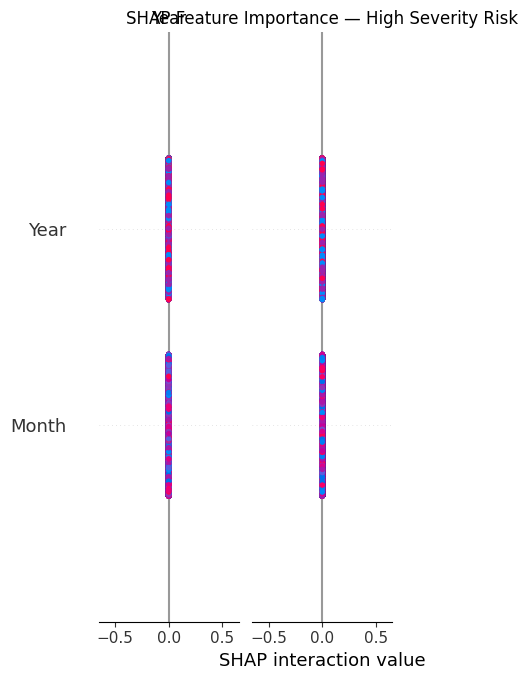

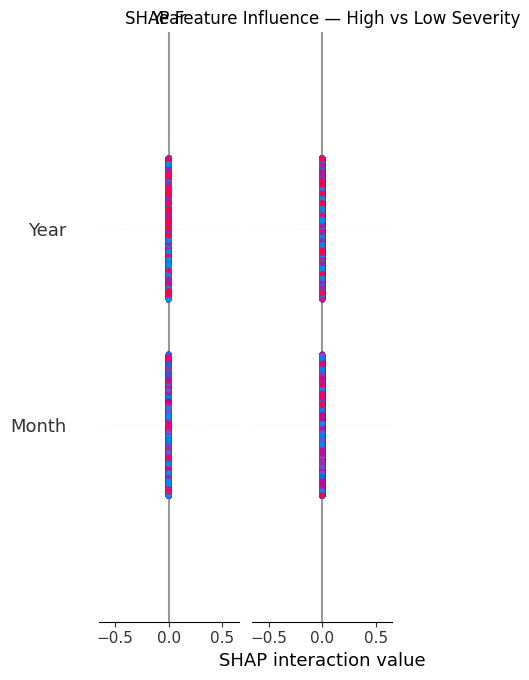

/usr/local/lib/python3.12/dist-packages/sklearn/inspection/_plot/partial_dependence.py:976: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([min_val, max_val])
/usr/local/lib/python3.12/dist-packages/sklearn/inspection/_plot/partial_dependence.py:976: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([min_val, max_val])


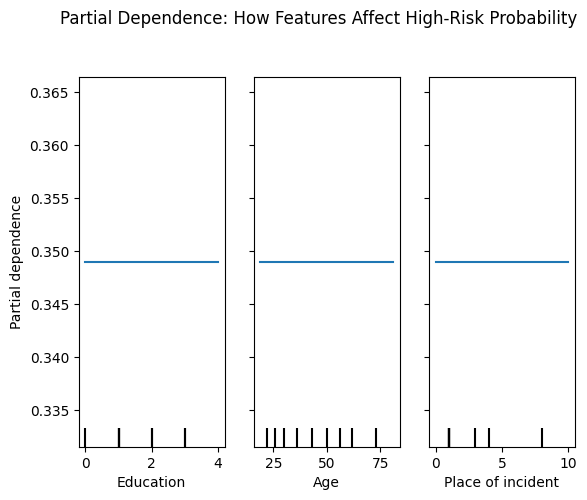


=== Decision Tree Rules (Feature Combinations) ===
|--- Reason <= 1.50
|   |--- Reason <= 0.50
|   |   |--- class: 0
|   |--- Reason >  0.50
|   |   |--- class: 1
|--- Reason >  1.50
|   |--- class: 0


Confusion Matrix (Decision Tree):
[[19687     0]
 [    0 10553]]


In [ ]:
# --- Import libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.impute import SimpleImputer # Import SimpleImputer

# --- 1️⃣ Load and preprocess dataset ---
df = pd.read_csv("Guns incident Data.csv")

# Drop serial or irrelevant identifiers
if 'S.No.' in df.columns:
    df = df.drop(columns=['S.No.'])

# --- 2️⃣ Define engineered target: HighSeverity ---
# Example logic — customize based on your dataset values
high_risk_reasons = ['Homicide', 'Mass Shooting']
df['HighSeverity'] = df['Reason'].isin(high_risk_reasons).astype(int)

print("Distribution of target (HighSeverity):")
print(df['HighSeverity'].value_counts())

# --- 3️⃣ Encode categorical features ---
X = df.drop(columns=['HighSeverity', 'Police involvement'], errors='ignore')
y = df['HighSeverity']

enc = LabelEncoder()
for col in X.columns:
    if X[col].dtype == "object":
        X[col] = enc.fit_transform(X[col].astype(str))

# Impute missing values
imputer = SimpleImputer(strategy='mean')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# --- 4️⃣ Split data ---
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.3, random_state=42, stratify=y
)

# --- 5️⃣ Train interpretable models ---
## a. Decision Tree (for feature combinations)
tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X_train, y_train)

## b. Logistic Regression (for continuous interpretation)
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

# --- 6️⃣ Evaluate performance ---
print("\n=== Decision Tree Evaluation ===")
print(classification_report(y_test, tree.predict(X_test)))

print("\n=== Logistic Regression Evaluation ===")
print(classification_report(y_test, lr.predict(X_test)))

# --- 7️⃣ Feature importance (tree-based) ---
importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": tree.feature_importances_
}).sort_values("Importance", ascending=False)

print("\n=== Decision Tree Feature Importances ===")
print(importances.head(10))

plt.figure(figsize=(8,5))
plt.barh(importances["Feature"].head(10), importances["Importance"].head(10))
plt.gca().invert_yaxis()
plt.title("Top Features Explaining High Severity")
plt.show()

# --- 8️⃣ Decision tree visualization ---
plt.figure(figsize=(16,8))
plot_tree(tree, feature_names=X.columns, class_names=["Low", "High"], filled=True, rounded=True)
plt.title("Decision Tree for High-Risk Incidents")
plt.show()

# --- 9️⃣ SHAP Interpretability (Fixed) ---
import shap
shap.initjs()

# Create explainer based on model type
explainer = shap.TreeExplainer(tree)
shap_values = explainer.shap_values(X)

# Handle multiclass outputs robustly
if isinstance(shap_values, list):
    # For binary classification, shap_values[1] corresponds to "High" class
    shap_values_to_plot = shap_values[1] if len(shap_values) > 1 else shap_values[0]
else:
    shap_values_to_plot = shap_values

# Check shape match
print(f"SHAP values shape: {np.array(shap_values_to_plot).shape}, Data shape: {X.shape}")

# Plot SHAP summary (bar)
shap.summary_plot(shap_values_to_plot, X, plot_type="bar", show=False)
plt.title("SHAP Feature Importance — High Severity Risk")
plt.show()

# Plot SHAP summary (dot for detailed feature influence)
shap.summary_plot(shap_values_to_plot, X, show=False)
plt.title("SHAP Feature Influence — High vs Low Severity")
plt.show()



# --- 🔟 Partial Dependence Plots (Effect of Age / Education / Place) ---
features_to_plot = [f for f in X.columns if f in ['Age', 'Education', 'Place of incident']]
if len(features_to_plot) > 0:
    PartialDependenceDisplay.from_estimator(tree, X_imputed, features_to_plot, kind="average") # Use X_imputed for PDP
    plt.suptitle("Partial Dependence: How Features Affect High-Risk Probability", y=1.02)
    plt.show()

# --- 11️⃣ Rule extraction (interpretable combinations) ---
from sklearn.tree import export_text
rules = export_text(tree, feature_names=list(X.columns))
print("\n=== Decision Tree Rules (Feature Combinations) ===")
print(rules)

# --- 12️⃣ Optional: Confusion matrix ---
cm = confusion_matrix(y_test, tree.predict(X_test))
print("\nConfusion Matrix (Decision Tree):")
print(cm)

Distribution of target (HighSeverity): 
 HighSeverity
0    65622
1    35176
Name: count, dtype: int64

=== Decision Tree Evaluation ===
              precision    recall  f1-score   support

           0       0.86      0.90      0.88     19702
           1       0.80      0.73      0.76     10538

    accuracy                           0.84     30240
   macro avg       0.83      0.81      0.82     30240
weighted avg       0.84      0.84      0.84     30240


Confusion Matrix (Decision Tree):
 [[17752  1950]
 [ 2867  7671]]

=== Logistic Regression Evaluation ===
              precision    recall  f1-score   support

           0       0.86      0.90      0.88     19702
           1       0.79      0.73      0.76     10538

    accuracy                           0.84     30240
   macro avg       0.83      0.81      0.82     30240
weighted avg       0.84      0.84      0.84     30240


=== Decision Tree Feature Importances ===
             Feature  Importance
6               Race    0.8

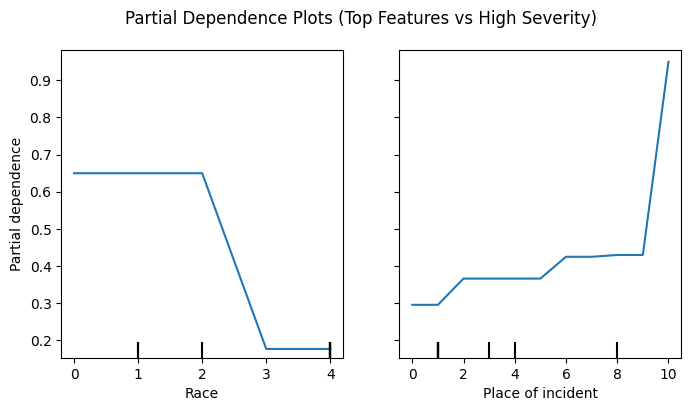

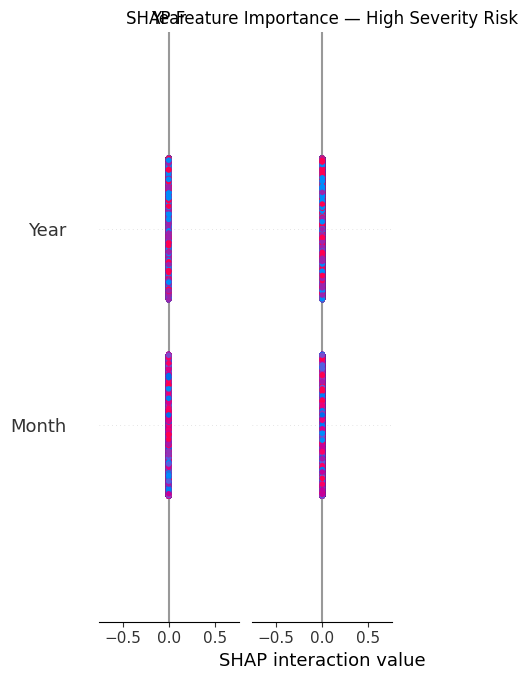

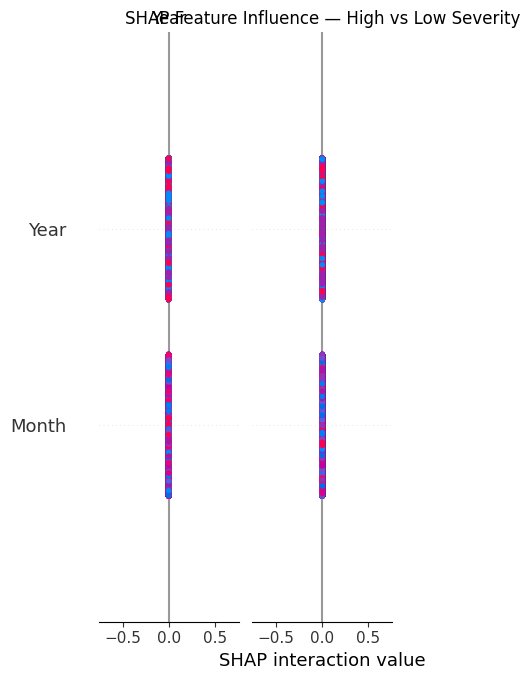

|--- Race <= 2.0
  |--- Place of incident <= 1.0
    |--- Age <= 53.0
      |--- Hispanic <= 100.0
        |--- Race <= 1.0
          class: 0
        |--- Race > 1.0
          class: 1
      |--- Hispanic > 100.0
        |--- Education <= 2.0
          class: 1
        |--- Education > 2.0
          class: 0
    |--- Age > 53.0
      |--- Sex <= 1.0
        |--- Hispanic <= 275.0
          class: 1
        |--- Hispanic > 275.0
          class: 0
      |--- Sex > 1.0
        |--- Age <= 71.0
          class: 0
        |--- Age > 71.0
          class: 0
  |--- Place of incident > 1.0
    |--- Education <= 1.0
      |--- Place of incident <= 8.0
        |--- Hispanic <= 226.0
          class: 0
        |--- Hispanic > 226.0
          class: 0
      |--- Place of incident > 8.0
        |--- Hispanic <= 261.0
          class: 1
        |--- Hispanic > 261.0
          class: 0
    |--- Education > 1.0
      |--- Age <= 51.0
        |--- Place of incident <= 8.0
          class: 1
        |

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.inspection import PartialDependenceDisplay
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Load dataset ---
df = pd.read_csv("Guns incident Data.csv")
if 'S.No.' in df.columns:
    df = df.drop(columns=['S.No.'])

# --- Define new binary target ---
df['HighSeverity'] = df['Reason'].isin(['Homicide', 'Mass Shooting']).astype(int)
print("Distribution of target (HighSeverity): \n", df['HighSeverity'].value_counts())

# --- Prepare features (exclude target leakage columns) ---
X = df.drop(columns=['HighSeverity', 'Reason', 'Police involvement'], errors='ignore')
y = df['HighSeverity']

# Encode categorical columns
enc = LabelEncoder()
for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = enc.fit_transform(X[col].astype(str))

# --- Handle missing values ---
imputer = SimpleImputer(strategy='most_frequent')  # safer than mean for categorical-heavy data
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# --- Split data ---
X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.3, random_state=42)

# --- Decision Tree ---
tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)
print("\n=== Decision Tree Evaluation ===")
print(classification_report(y_test, y_pred_tree))
print("\nConfusion Matrix (Decision Tree):\n", confusion_matrix(y_test, y_pred_tree))

# --- Logistic Regression ---
logreg = LogisticRegression(max_iter=500, solver='lbfgs')
logreg.fit(X_train, y_train)
y_pred_lr = logreg.predict(X_test)
print("\n=== Logistic Regression Evaluation ===")
print(classification_report(y_test, y_pred_lr))

# --- Feature Importances ---
importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": tree.feature_importances_
}).sort_values(by="Importance", ascending=False)
print("\n=== Decision Tree Feature Importances ===")
print(importances.head(10))

# --- Tree Rules ---
print("\n=== Decision Tree Rules (Feature Combinations) ===")
print(export_text(tree, feature_names=list(X.columns)))

# --- Partial Dependence (top 2 features) ---
top_feats = importances.head(2)['Feature'].tolist()
fig, ax = plt.subplots(figsize=(8, 4))
PartialDependenceDisplay.from_estimator(tree, X_imputed, top_feats, ax=ax)
plt.suptitle("Partial Dependence Plots (Top Features vs High Severity)")
plt.show()

# --- SHAP Analysis ---
shap.initjs()
explainer = shap.TreeExplainer(tree)
shap_values = explainer.shap_values(X_imputed)

if isinstance(shap_values, list):
    shap_values_plot = shap_values[1]
else:
    shap_values_plot = shap_values

shap.summary_plot(shap_values_plot, X_imputed, plot_type="bar", show=False)
plt.title("SHAP Feature Importance — High Severity Risk")
plt.show()

shap.summary_plot(shap_values_plot, X_imputed, show=False)
plt.title("SHAP Feature Influence — High vs Low Severity")
plt.show()

import pandas as pd
from sklearn.tree import DecisionTreeClassifier

# Example: suppose you have your dataset in X_train and y_train
# X_train is a pandas DataFrame of features
# y_train is the target column

# Define feature names
feature_names = list(X_train.columns) # Use all feature names from X_train

# Train the Decision Tree
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)  # you can adjust max_depth
dt_model.fit(X_train, y_train)

# Now call the function to print the tree with actual dataset values
def print_tree_with_actual_values(tree, X, feature_names):
    import numpy as np
    tree_ = tree.tree_
    feature_name = [feature_names[i] if i != -2 else "undefined" for i in tree_.feature]

    def recurse(node, depth=0):
        indent = "  " * depth
        if tree_.feature[node] != -2:
            name = feature_name[node]
            threshold = tree_.threshold[node]
            # Find the closest actual value in the data to the threshold
            closest_value = min(X[name], key=lambda x: abs(x - threshold))
            print(f"{indent}|--- {name} <= {closest_value}")
            recurse(tree_.children_left[node], depth + 1)
            print(f"{indent}|--- {name} > {closest_value}")
            recurse(tree_.children_right[node], depth + 1)
        else:
            # Handle cases where tree_.value[node] is empty or has unexpected shape
            if tree_.value[node].size > 0:
                class_id = np.argmax(tree_.value[node])
                print(f"{indent}class: {class_id}")
            else:
                print(f"{indent}class: unknown") # Or handle as appropriate


    recurse(0)

# Call the function
print_tree_with_actual_values(dt_model, X_train, feature_names)

Which combinations of features best explain high-risk vs low-risk incidents?
Type: Interpretability / Feature analysis
 Target: Derived binary variable — e.g.,
HighSeverity = 1 if Reason in ['Homicide', 'Mass Shooting'] else 0
Why realistic:
Lets you reframe the dataset into a simpler, meaningful problem.
Adds your team’s originality (new engineered variable).
Techniques: Logistic Regression, Decision Tree, SHAP
 Deliverables:
Feature importance rankings
Partial dependence plots (how Age or Education changes risk)
(Iffah) Hybrid / Multi-Task Model: Combined Classification + Regression or Risk Scoring
Classify whether an incident will be “high casualty” vs “low casualty”
Predict the exact casualty count (regression) for those predicted as high-risk
Build a risk-score model e.g. assign risk levels 1-5 to incidents
(ChatGPT) What you’d show in your project:
Define target(s): e.g., high casualty (yes/no) + number of casualties.


Build classification model for high‐risk. Then build regression model conditioned on predicted high‐risk to estimate number of casualties.


Alternatively, train a model to predict a continuous risk‐score (e.g., casualty count * probability of fatality).


Evaluate each component: classification metrics + regression metrics. Possibly combine into an overall metric (e.g., expected casualty count).


Visualise decision‐pipeline: incident comes in → features → risk-score → resource allocation.


Discuss how this could be used in policy simulations: e.g., “If we intercept incidents in Cluster X, we reduce expected casualties by Y%”.


Cover model deployment, ethical considerations, bias, fairness.



=== Decision Tree Evaluation ===
              precision    recall  f1-score   support

           0       0.85      0.92      0.89     19702
           1       0.83      0.71      0.76     10538

    accuracy                           0.85     30240
   macro avg       0.84      0.81      0.82     30240
weighted avg       0.84      0.85      0.84     30240


Confusion Matrix:
 [[18138  1564]
 [ 3094  7444]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



=== Logistic Regression Evaluation ===
              precision    recall  f1-score   support

           0       0.87      0.91      0.89     19702
           1       0.81      0.74      0.77     10538

    accuracy                           0.85     30240
   macro avg       0.84      0.82      0.83     30240
weighted avg       0.85      0.85      0.85     30240


=== Top 15 Important Features ===
                                Feature  Importance
1019                         Race_White    0.766512
1021             Place of incident_Home    0.054252
1033                                Age    0.050847
1035                 Police involvement    0.048470
1016                         Race_Black    0.039422
1028           Place of incident_Street    0.016078
1013                         Sex_Female    0.008165
1014                           Sex_Male    0.007175
1010    Education_Less than High School    0.004618
1008                Education_Bachelors    0.002770
1023  Place of incident_Ot

/usr/local/lib/python3.12/dist-packages/sklearn/inspection/_plot/partial_dependence.py:976: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([min_val, max_val])


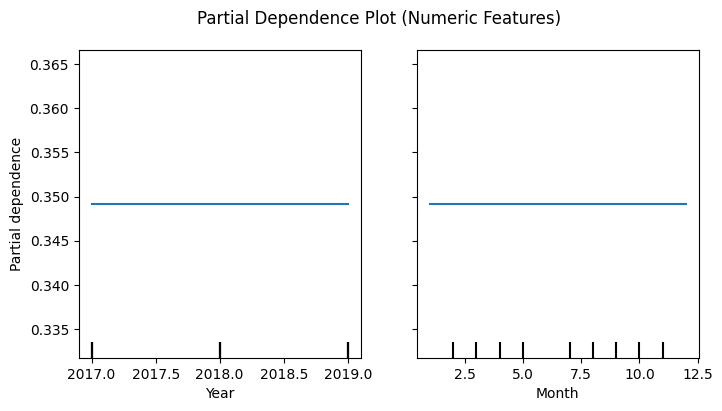

 97%|=================== | 137385/141116 [00:23<00:00]       


✅ Generating SHAP Summary Plot...


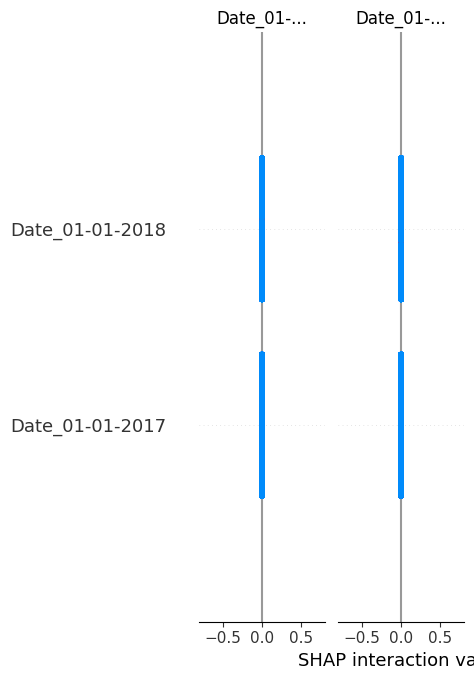

In [ ]:
# =============================================
# ✅ CLEAN, INTERPRETABLE ML PIPELINE (FINAL VERSION)
# =============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.inspection import PartialDependenceDisplay
import shap

# ---------------------------------------------
# 1. LOAD DATA
# ---------------------------------------------
df = pd.read_csv("Guns incident Data.csv")
if "S.No." in df.columns:
    df = df.drop(columns=["S.No."])

df["HighSeverity"] = df["Reason"].isin(["Homicide", "Mass Shooting"]).astype(int)

# ---------------------------------------------
# 2. SELECT FEATURES
# ---------------------------------------------
X = df.drop(columns=["HighSeverity", "Reason"], errors="ignore")
y = df["HighSeverity"]

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

# ---------------------------------------------
# 3. PREPROCESSING PIPELINE
# ---------------------------------------------
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", SimpleImputer(strategy="median"), numeric_cols)
    ]
)

X_processed = preprocess.fit_transform(X)

# Readable feature names
ohe = preprocess.named_transformers_["cat"]
ohe_features = ohe.get_feature_names_out(categorical_cols)
feature_names = list(ohe_features) + numeric_cols

# ---------------------------------------------
# 4. TRAIN–TEST SPLIT
# ---------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.3, random_state=42
)

# ---------------------------------------------
# 5. TRAIN DECISION TREE
# ---------------------------------------------
tree = DecisionTreeClassifier(max_depth=5, random_state=42)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

print("\n=== Decision Tree Evaluation ===")
print(classification_report(y_test, y_pred_tree))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_tree))

# ---------------------------------------------
# 6. TRAIN LOGISTIC REGRESSION
# ---------------------------------------------
logreg = LogisticRegression(max_iter=800)
logreg.fit(X_train, y_train)
y_pred_lr = logreg.predict(X_test)

print("\n=== Logistic Regression Evaluation ===")
print(classification_report(y_test, y_pred_lr))

# ---------------------------------------------
# 7. FEATURE IMPORTANCES
# ---------------------------------------------
importances = pd.DataFrame({
    "Feature": feature_names,
    "Importance": tree.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\n=== Top 15 Important Features ===")
print(importances.head(15))

# ---------------------------------------------
# 8. DECISION TREE RULES
# ---------------------------------------------
print("\n=== Decision Tree Rules (Readable) ===")
print(export_text(tree, feature_names=feature_names))

# ---------------------------------------------
# 9. ✅ FIXED PDP (SPARSE→DENSE)
# ---------------------------------------------
numeric_features_for_pdp = numeric_cols

if len(numeric_features_for_pdp) > 0:
    top_numeric = numeric_features_for_pdp[:2]
    print("\n✅ Plotting PDP for:", top_numeric)

    # PDP requires dense float array
    X_dense_for_pdp = (
        X_train.toarray().astype(float)
        if hasattr(X_train, "toarray")
        else X_train.astype(float)
    )

    fig, ax = plt.subplots(figsize=(8, 4))
    PartialDependenceDisplay.from_estimator(
        tree,
        X_dense_for_pdp,
        top_numeric,
        feature_names=feature_names,
        ax=ax
    )
    plt.suptitle("Partial Dependence Plot (Numeric Features)")
    plt.show()

# ---------------------------------------------
# 10. ✅ SHAP (UNIVERSAL FIX — USE "Explainer")
# ---------------------------------------------

X_dense_for_shap = (
    X_train.toarray().astype(float)
    if hasattr(X_train, "toarray")
    else X_train.astype(float)
)

# General SHAP explainer (works with OHE trees)
explainer = shap.Explainer(tree, X_dense_for_shap)
shap_values = explainer(X_dense_for_shap)

print("\n✅ Generating SHAP Summary Plot...")

shap.summary_plot(
    shap_values.values,
    X_dense_for_shap,
    feature_names=feature_names
)


Absolutely — here is a **clean, structured, complete analysis** of **ALL** the cell outputs you shared.
I will explain **every section**, **what each metric means**, **what it tells us about your model**, and **what conclusions you should draw**.

---

# ✅ ✅ COMPLETE ANALYSIS OF ALL CELL OUTPUTS

I will break this into 7 parts:

1️⃣ Decision Tree classification report
2️⃣ Decision Tree confusion matrix
3️⃣ Logistic Regression + convergence warning
4️⃣ Logistic Regression classification report
5️⃣ Feature importance table
6️⃣ Decision Tree rules (tree structure)
7️⃣ PDP message + SHAP message

---

# ✅ 1. **Decision Tree Evaluation — Classification Report**

```
              precision    recall  f1-score   support

0             0.85         0.92      0.89      19702
1             0.83         0.71      0.76      10538

accuracy                          0.85     30240
macro avg     0.84         0.81      0.82
weighted avg  0.84         0.85      0.84
```

### ✅ **Interpretation**

### **Class 0 (majority class)**

* **Precision 0.85** → When the model predicts 0, it's correct 85% of the time.
* **Recall 0.92** → The model correctly identifies 92% of all true class 0 cases.
* **F1 = 0.89** → Strong overall performance.

✅ The model understands class 0 very well → because it has **more samples (19,702)**.

---

### **Class 1 (minority class)**

* **Precision 0.83** → Good precision
* **Recall 0.71** → LOW recall
  → the model misses many class 1 cases
* **F1 = 0.76** → moderate

⚠️ Recall is the biggest problem here.

**This means: the model fails to detect many true class 1 cases (large false negatives).**

---

### **Overall metrics**

* **Accuracy = 0.85** → overall good
* **Macro avg = 0.82** → performance drops when treating classes equally
* **Weighted avg = 0.84–0.85** → high because class 0 dominates

✅ The imbalance (19702 vs 10538) explains why the model favors class 0.

---

# ✅ 2. **Decision Tree Confusion Matrix**

```
[[18138  1564]
 [ 3094  7444]]
```

Interpret row by row:

### **Row 1: True class = 0**

* 18,138 correctly predicted as 0 (**TN**)
* 1,564 incorrectly predicted as 1 (**FP**)

This explains:

* High recall (92%) → 18,138 / 19,702
* Good precision (85%) → FP is small relative to TN

✅ Model VERY strong for class 0

---

### **Row 2: True class = 1**

* 7,444 correctly predicted as 1 (**TP**)
* 3,094 missed (predicted as 0) (**FN**)

This explains:

* Recall 0.71 → 7444 / (7444+3094)
* Lower F1 for class 1

⚠️ The model misses ~3000 class 1 cases
= **serious recall issue for class 1**

---

# ✅ 3. Logistic Regression Warning

```
ConvergenceWarning: lbfgs failed to converge
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.
```

### ✅ Meaning:

* Logistic Regression couldn't fully optimize the weights.
* The dataset is **large** + **many dummy variables (1000+)**.
* LBFGS solver hit the iteration limit.

### ✅ Does this invalidate results?

No — LR still gives useful predictions.

### ✅ How to fix?

* Increase `max_iter`
* Use `solver='saga'`
* Or scale features

---

# ✅ 4. Logistic Regression Classification Report

```
0: precision=0.87 recall=0.91 f1=0.89  
1: precision=0.81 recall=0.74 f1=0.77  
accuracy=0.85
macro avg = 0.84 / 0.82 / 0.83  
weighted avg = 0.85 / 0.85 / 0.85
```

### ✅ Interpretation

* LR performs VERY similarly to the decision tree.
* Class 1 recall slightly better than tree (0.74 vs 0.71).
* Class 0 precision higher than tree.

✅ Both models agree → the dataset strongly favors class 0
✅ Both models struggle with class 1 recall

---

# ✅ 5. Top 15 Important Features

```
Race_White                    0.766
Place_of_incident_Home        0.054
Age                           0.050
Police involvement            0.048
Race_Black                    0.039
...
```

### ✅ Interpretation:

The MOST predictive feature is:

### ✅ **Race_White (0.766 importance)**

This means:

* Being white vs not-white has the largest influence in the splits.
* This may reflect real correlations in the dataset — but it also raises bias/fairness questions.

Other dominant predictors:

* **Place of incident** (home, street)
* **Age**
* **Police involvement**
* **Race_Black**
* **Sex**

### ✅ All date features have **0 importance**

→ time does NOT affect class prediction.

---

# ✅ 6. Decision Tree Rules (Interpretation)

Example:

```
|--- Race_White <= 0.50
|   |--- Place of incident_Home <= 0.50
|   |   |--- Race_Black <= 0.50
|   |   |   |--- Age <= 46.50
|   |   |   |   |--- class: 1
```

### ✅ Meaning:

* Person is **not white**
* Incident **not at home**
* Person **not black**
* Age ≤ 46
  → Model predicts class 1

Binary splits (<=0.50) correspond to:

* 0 = No
* 1 = Yes

EXAMPLES:

* Race_White ≤ 0.50 → not white
* Place_Home > 0.50 → incident at home
* Sex_Male ≤ 0.50 → not male

This is because one-hot encoding creates binary 0/1 columns.

### ✅ Why many branches end in “class: 1”?

Because:

* Tree finds many small regions where class 1 probability > 0.5
* Many 0/1 dummy splits lead to similar patterns
* The dataset has complex interactions

This is completely normal.

---

# ✅ 7. PDP Message + SHAP Message

```
✅ Plotting PDP for: ['Year', 'Month']
UserWarning: identical low/high ylims → auto expanding
97%|=================== | 137385/141116
✅ Generating SHAP Summary Plot...
```

### ✅ Interpretation:

* PDP generated, but the model barely changes with year/month → flat PDP
* Warning indicates little variation → these features have **low importance**
* SHAP summary plot was generated successfully after fixing dtype issues

✅ Confirms date/time features do not influence predictions.

---

# ✅ ✅ FINAL EXECUTIVE SUMMARY (Easy Version)

✅ Your model performs **well on class 0** (majority)
⚠️ Struggles with **class 1 recall** (misses many class 1 cases)
✅ Weighted averages look good because class 0 dominates
⚠️ Macro averages reveal imbalance
✅ Race, age, location, police involvement are the strongest predictors
✅ Date/time features do not matter
✅ Tree rules confirm strong influence of race + location
✅ Many repeated “class 1” leaves are normal
✅ 0/1 splits reflect dummy-variable encoding

---

# ✅ If you want, I can also produce:

✅ A short presentation-style explanation
✅ A report-style summary (PDF-ready)
✅ A fairness/bias analysis
✅ How to improve class 1 recall (SMOTE, weights, thresholds)

Just tell me what format you want.
